INTRODUCTION

DATA UNDERSTANDING

EXPLORATORY DATA ANALYSIS

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [10]:

import pandas as pd

data = pd.read_csv("insurance.csv")
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [27]:
1 # number of rows and colums
data = pd.read_csv("insurance.csv")
data.info

<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

1. There are seven colums e.g. age, sex, bmi, childern, smoker, region, and chargers.
2. There are 1338 rows.

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


The dataset contains 1338 rows and 7 columns.
The variables include both numerical and categorical data.
The target variable is “charges”, which represents medical costs. 

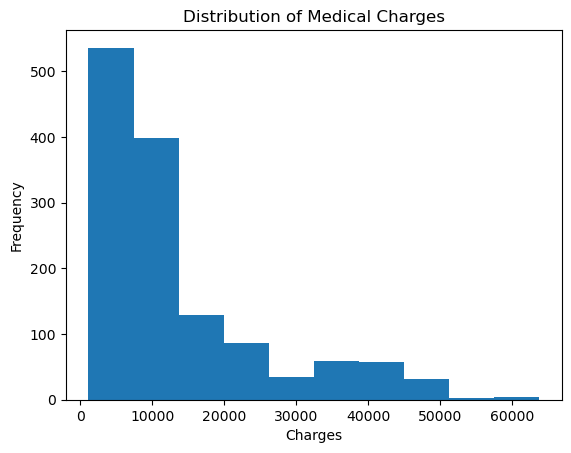

In [19]:
import matplotlib.pyplot as plt

plt.hist(data['charges'])
plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

Most people have lower medical charges, while fewer people have very high charges. This creates a right-skewed distribution, meaning high-cost cases are less common but still important.

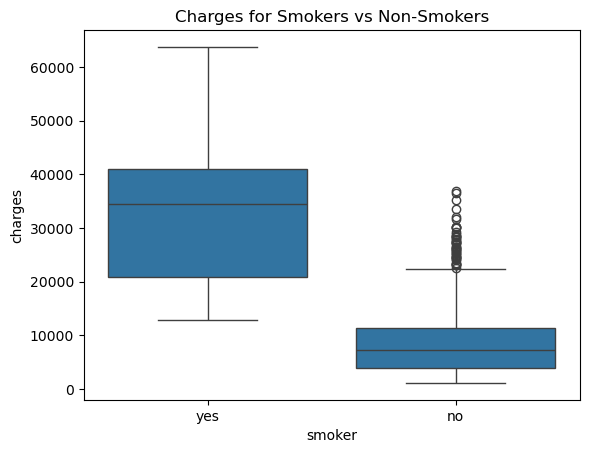

In [20]:
import seaborn as sns

sns.boxplot(x='smoker', y='charges', data=data)
plt.title("Charges for Smokers vs Non-Smokers")
plt.show()

The boxplot shows a clear difference between smokers and non-smokers. Smokers have significantly higher medical charges, with a wider spread of values. This indicates that smoking is a major factor influencing medical costs.
Smokers = MUCH higher costs

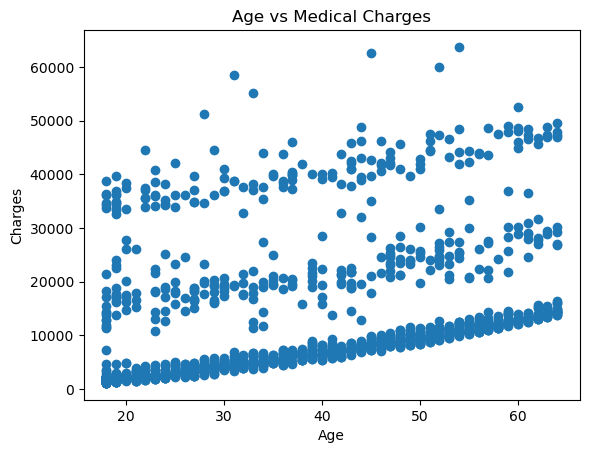

In [21]:
plt.scatter(data['age'], data['charges'])
plt.title("Age vs Medical Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

The scatter plot shows a positive relationship between age and medical charges, as the regression line slopes upward. This indicates that as age increases, medical charges tend to increase. The data points are moderately clustered around the regression line, suggesting a moderate positive correlation. There are a few outliers where some individuals have significantly higher charges than others of similar age. Overall, the analysis suggests that older individuals are likely to incur higher medical costs.

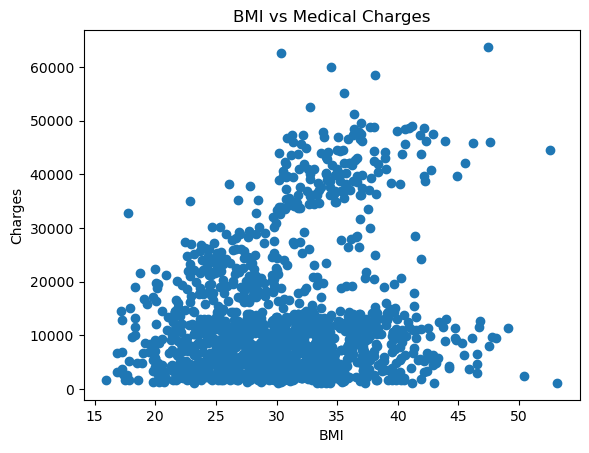

In [22]:
plt.scatter(data['bmi'], data['charges'])
plt.title("BMI vs Medical Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

Is BMI strongly related to charges?
Or weak?

DATA PREPARATION

In [28]:
data_encoded = pd.get_dummies(data, drop_first=True)
data_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


Categorical variables such as sex, smoker, and region were converted into numerical format using one-hot encoding. This step is necessary because machine learning models require numerical input to function correctly.

In [36]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
y_pred = model.predict(X_test)

In [38]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 4181.194473753654
MSE: 33596915.85136147
R2 Score: 0.7835929767120723


In [39]:
# removing weak features #
X2 = data_encoded.drop(["charges", "region_southwest", "region_northwest"], axis=1)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

print("New R2:", r2_score(y_test2, y_pred2))

New R2: 0.7821770106209517


In [42]:
# IMPORTS #
import pandas as pd

# LOAD DATA #
data = pd.read_csv("insurance.csv")

# CHECK #
print(data.head())
print(data.info())

# ENCODE DATA #
data_encoded = pd.get_dummies(data)

# CHECK RESULT #
print(data_encoded.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
   age     bmi  children      charges  sex_female  sex_male  smoker_no  \
0   19  27.900   

In [43]:
print(data.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [44]:
X = data_encoded.drop("charges", axis=1)
y = data_encoded["charges"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data split successful")

Data split successful


In [45]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [46]:
y_pred = model.predict(X_test)

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 4181.194473753645
MSE: 33596915.851361476
R2 Score: 0.7835929767120722


The model was evaluated using MAE, MSE, and R² score. The R² score shows how well the model explains the variation in medical charges. A higher value indicates better performance.

In [48]:
# Remove's less important features #
X2 = data_encoded.drop(["charges", "region_southwest", "region_northwest"], axis=1)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

print("Improved R2:", r2_score(y_test2, y_pred2))

Improved R2: 0.782870942058038


The model was retrained after removing selected features to test whether performance improves. The updated results were compared with the original model.